In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report


df = pd.read_csv("CreditCard.csv")

print("Dataset loaded successfully")
print(df.head())


# X = all columns except the answer column
# y = the answer column we want to predict

X = df.drop("Class", axis=1)
y = df["Class"]


# Training data teaches the model
# Testing data checks if the model learned correctly

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# Create the model
model = LogisticRegression(max_iter=1000)


# Train the model
model.fit(X_train, y_train)


# Make predictions
y_pred = model.predict(X_test)


# Evaluate the model
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))


# Save train/test data
np.save("X_train.npy", X_train.to_numpy())
np.save("X_test.npy", X_test.to_numpy())
np.save("y_train.npy", y_train.to_numpy())
np.save("y_test.npy", y_test.to_numpy())

print("Data splits saved successfully")

Dataset loaded successfully
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

c:\Projects\Fraud-Detection-Pipeline\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Confusion Matrix ---
[[56848    16]
 [   30    68]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.69      0.75        98

    accuracy                           1.00     56962
   macro avg       0.90      0.85      0.87     56962
weighted avg       1.00      1.00      1.00     56962

Data splits saved successfully


APPLYING SMOTE


In [2]:
# Import libraries
import numpy as np

from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


# Load saved train/test data
X_train = np.load("X_train.npy")
X_test = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")


# Check original class imbalance
print("Original training class counts:")
print(np.bincount(y_train))

# np.bincount output:
# index 0 = legitimate transactions
# index 1 = fraud transactions


# Balance only the training data using SMOTE
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train,
    y_train
)


# Check new balanced class counts
print("Balanced training class counts:")
print(np.bincount(y_train_balanced))


# Create Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)


# Train model on balanced data
model.fit(X_train_balanced, y_train_balanced)


# Predict using untouched test features
y_pred = model.predict(X_test)


# Evaluate using untouched real test labels
print(classification_report(
    y_test,
    y_pred,
    target_names=["Legitimate", "Fraud"],
    digits=4
))

Original training class counts:
[227451    394]
Balanced training class counts:
[227451 227451]
              precision    recall  f1-score   support

  Legitimate     0.9998    0.9892    0.9945     56864
       Fraud     0.1257    0.8980    0.2206        98

    accuracy                         0.9891     56962
   macro avg     0.5628    0.9436    0.6075     56962
weighted avg     0.9983    0.9891    0.9932     56962



c:\Projects\Fraud-Detection-Pipeline\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Applying SMOTE and class weights and comparing the better method



In [3]:
import numpy as np
import pandas as pd

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_fscore_support


# ========================================================
# STEP 1: LOAD DATA
# ========================================================

print("Loading the saved training and testing data...")

X_train = np.load("X_train.npy")
X_test = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")

print("Data loaded successfully!")
print("Number of fraud cases in the original training data:", np.sum(y_train))

summary_metrics = []


# ========================================================
# EXPERIMENT 1: SMOTE + SCALING
# ========================================================
# StandardScaler makes all columns use a similar scale.
# This helps Logistic Regression learn much better.

print("\nExperiment 1: Training model using SMOTE + scaling...")

smote_model = Pipeline([
    ("scaler", StandardScaler()),

    ("smote", SMOTE(random_state=42)),

    ("logistic_regression", LogisticRegression(
        max_iter=2000,
        solver="lbfgs",
        random_state=42
    ))
])

smote_model.fit(X_train, y_train)

smote_predictions = smote_model.predict(X_test)

smote_precision, smote_recall, smote_f1, _ = precision_recall_fscore_support(
    y_test,
    smote_predictions,
    average=None
)

summary_metrics.append({
    "Approach": "1. SMOTE + Scaling",
    "Fraud Precision": round(smote_precision[1], 4),
    "Fraud Recall": round(smote_recall[1], 4)
})


# ========================================================
# EXPERIMENT 2: CLASS WEIGHTS + SCALING
# ========================================================

print("\nExperiment 2: Training model using class weights + scaling...")

weighted_model = Pipeline([
    ("scaler", StandardScaler()),

    ("logistic_regression", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        solver="lbfgs",
        random_state=42
    ))
])

weighted_model.fit(X_train, y_train)

weighted_predictions = weighted_model.predict(X_test)

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    weighted_predictions,
    average=None
)

summary_metrics.append({
    "Approach": "2. Class Weights + Scaling",
    "Fraud Precision": round(weighted_precision[1], 4),
    "Fraud Recall": round(weighted_recall[1], 4)
})


# ========================================================
# FINAL COMPARISON
# ========================================================

print("\n" + "=" * 50)
print("OPTIMIZATION COMPARISON MATRIX")
print("=" * 50)

comparison_table = pd.DataFrame(summary_metrics)

print(comparison_table.to_string(index=False))

print("=" * 50)

Loading the saved training and testing data...
Data loaded successfully!
Number of fraud cases in the original training data: 394

Experiment 1: Training model using SMOTE + scaling...

Experiment 2: Training model using class weights + scaling...

OPTIMIZATION COMPARISON MATRIX
                  Approach  Fraud Precision  Fraud Recall
        1. SMOTE + Scaling           0.0578        0.9184
2. Class Weights + Scaling           0.0610        0.9184


In [4]:
import numpy as np

from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

from xgboost import XGBClassifier


print("We are implementing Advanced Tree Models and Threshold Tuning!")


# ========================================================
# STEP 1: LOAD THE SAVED DATA
# ========================================================

print("\nLoading the saved training and testing data...")

X_train = np.load("X_train.npy")
X_test = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")

print("Data loaded successfully!")
print("Original training class counts:")
print(np.bincount(y_train))


# ========================================================
# STEP 2: APPLY SMOTE
# ========================================================
# Random Forest and XGBoost can train on SMOTE-balanced data.
# SMOTE creates extra fraud examples so both classes are balanced.

print("\nApplying SMOTE to balance the training data...")

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("New training class counts after SMOTE:")
print(np.bincount(y_train_smote))


# ========================================================
# STEP 3: TRAIN RANDOM FOREST
# ========================================================
# Random Forest builds many decision trees.
# Each tree votes, and the final answer is based on the majority vote.

print("\nTraining Random Forest model...")

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_smote, y_train_smote)

random_forest_predictions = random_forest_model.predict(X_test)


# ========================================================
# STEP 4: TRAIN XGBOOST
# ========================================================
# XGBoost also uses trees, but it builds them one by one.
# Each new tree tries to fix mistakes made by the previous trees.

print("\nTraining XGBoost model...")

xgboost_model = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

xgboost_model.fit(X_train_smote, y_train_smote)


# ========================================================
# STEP 5: THRESHOLD TUNING
# ========================================================
# Normal prediction uses a threshold of 0.50.
#
# Example:
# If fraud probability >= 0.50, predict Fraud.
# If fraud probability < 0.50, predict Legitimate.
#
# Here we use 0.95, meaning:
# "Only call it fraud if the model is at least 95% confident."

print("\nGetting XGBoost fraud probabilities...")

xgboost_fraud_probabilities = xgboost_model.predict_proba(X_test)[:, 1]

custom_threshold = 0.95

xgboost_custom_predictions = (
    xgboost_fraud_probabilities >= custom_threshold
).astype(int)


# ========================================================
# STEP 6: FINAL REPORTS
# ========================================================

print("\n=======================================================")
print("FINAL COMPARISON")
print("=======================================================")

print("\nREPORT 1: RANDOM FOREST")
print("Default threshold: 0.50")
print(
    classification_report(
        y_test,
        random_forest_predictions,
        target_names=["Legitimate", "Fraud"],
        digits=4
    )
)

print("\nREPORT 2: XGBOOST")
print("Custom threshold:", custom_threshold)
print(
    classification_report(
        y_test,
        xgboost_custom_predictions,
        target_names=["Legitimate", "Fraud"],
        digits=4
    )
)

We are implementing Advanced Tree Models and Threshold Tuning!

Loading the saved training and testing data...
Data loaded successfully!
Original training class counts:
[227451    394]

Applying SMOTE to balance the training data...
New training class counts after SMOTE:
[227451 227451]

Training Random Forest model...

Training XGBoost model...

Getting XGBoost fraud probabilities...

FINAL COMPARISON

REPORT 1: RANDOM FOREST
Default threshold: 0.50
              precision    recall  f1-score   support

  Legitimate     0.9997    0.9997    0.9997     56864
       Fraud     0.8351    0.8265    0.8308        98

    accuracy                         0.9994     56962
   macro avg     0.9174    0.9131    0.9152     56962
weighted avg     0.9994    0.9994    0.9994     56962


REPORT 2: XGBOOST
Custom threshold: 0.95
              precision    recall  f1-score   support

  Legitimate     0.9997    0.9998    0.9998     56864
       Fraud     0.8913    0.8367    0.8632        98

    accuracy

Test data splits successfully loaded from disk.
Optimized XGBoost model loaded successfully from disk.
REPORT: XGBoost (Threshold 0.95)

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.93      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.96      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



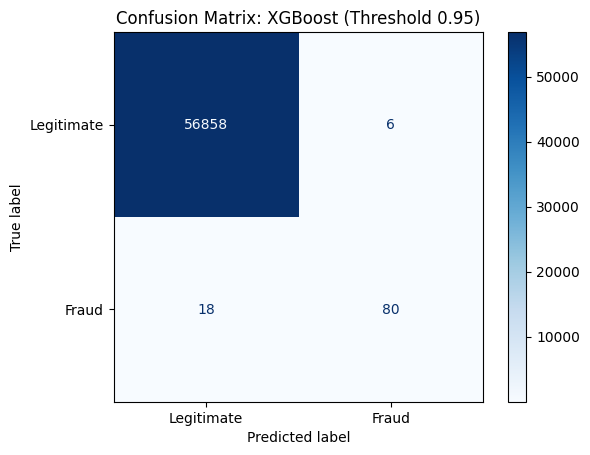

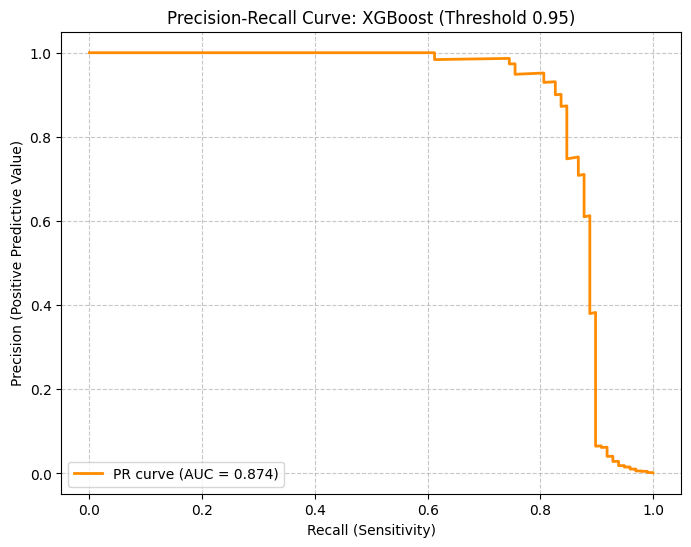

In [5]:
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, auc

def evaluate_fraud_model(y_true, y_pred, y_proba, model_name="Model"):
    """
    Generates critical evaluation metrics for imbalanced classification.
    """
    print(f"REPORT: {model_name}")
    
    # 1. Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["Legitimate", "Fraud"]))
    
    # 2. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Fraud"])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()
    
    # 3. Precision-Recall Curve (Gold Standard for Imbalanced Data)
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recall, precision)
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
    plt.xlabel('Recall (Sensitivity)')
    plt.ylabel('Precision (Positive Predictive Value)')
    plt.title(f'Precision-Recall Curve: {model_name}')
    plt.legend(loc="lower left")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# ==========================================
# EVALUATION EXECUTION
# ==========================================

try:
    # 1. Verify and load the test features and labels saved on disk
    if os.path.exists('X_test.npy') and os.path.exists('y_test.npy'):
        X_test = np.load('X_test.npy')
        y_test = np.load('y_test.npy')
        print("Test data splits successfully loaded from disk.")
    else:
        raise FileNotFoundError("Could not find 'X_test.npy' or 'y_test.npy' in the workspace root.")

    # 2. Load the optimized model generated from your tuning notebook
    if os.path.exists('best_xgb_model.pkl'):
        best_xgb_model = joblib.load('best_xgb_model.pkl')
        print("Optimized XGBoost model loaded successfully from disk.")
    else:
        raise FileNotFoundError("Could not find 'best_xgb_model.pkl'. Did you run the export cell in model_tuning.ipynb?")

    # 3. Predict probabilities for Class 1 (Fraud)
    y_proba_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

    # 4. Apply your custom threshold
    custom_threshold = 0.95
    y_pred_xgb = (y_proba_xgb >= custom_threshold).astype(int)

    # 5. Run the evaluation and plot generation
    evaluate_fraud_model(y_test, y_pred_xgb, y_proba_xgb, model_name=f"XGBoost (Threshold {custom_threshold})")

except FileNotFoundError as fnf_error:
    print("FILE MISSING ERROR:")
    print(f"[{fnf_error}]\n")
    print("HOW TO FIX THIS:")
    print("Ensure you have run the export step in 'model_tuning.ipynb' and that your data split cells have written files to your workspace root.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")